# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: `Francisco José Cerén Porto`
- Apellido2, Nombre2: `Miguel Angel Rendón Galvis`

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [1]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1069475303
cedula2 = 1023631713

In [2]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 16
Parámetros — alpha: 1.60, beta: 1.40, gamma: 0.200, ruido: 0.080
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

a) Que el spline interpole Z_data significa que el spline pasa exactamente por cada uno de los puntos con ruido, no lo suaviza, sino que lo copia. Si ajustara Z_true, buscaría la forma "limpia" de la superficie sin el ruido.

b) Usaríamos mínimos cuadrados si:

-Sabemos la forma matemática de la superficie (por ejemplo un plano) y queremos encontrar sus parámetros ignorando el ruido.

-Solo nos interesa la tendencia general o el patrón principal, no cada detalle con ruido.

-Cuando el sistema de ecuaciones lineales que resuelve el problema tiene más variables que ecuaciones.

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

a) La matriz  A  del sistema  Ac=z  se construye con 3 columnas:

-Primera columna: todos unos (para el término  c0 ).

-Segunda columna: los valores de las coordenadas x (para el coeficiente  c1 ).

-Tercera columna: los valores de las coordenadas y (para el coeficiente  c2 ).

b) El plano ajustado representa la mejor aproximación lineal de los datos Zdata (incluyendo ruido) en el sentido de mínimos cuadrados. Es útil porque nos da la tendencia de la superficie y ayuda a suavizar el ruido, ofreciendo una idea de la inclinación y altura promedio.

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**

a) Es necesario centrar los datos para que el PCA calcule los componentes principales como direcciones de máxima varianza alrededor del origen. Sin centrar, el primer componente principal podría simplemente reflejar la media de los datos en lugar de la dirección de mayor dispersión.

b) En el contexto de esta superficie, el primer componente principal (PC1) representa la dirección en el espacio (x, y, z) a lo largo de la cual la variación de los puntos de la superficie es máxima. Geométricamente, indica la orientación principal o la dirección de mayor elongación de la nube de puntos que describe la superficie.

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [3]:
# TODO P2.1: construir el spline bicúbico y evaluar en malla fina

# 1. Crear una malla fina de 100x100 puntos
x_fine = np.linspace(-3, 3, 100)
y_fine = np.linspace(-3, 3, 100)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

# 2. Construir el spline bicúbico
spline = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# 3. Evaluar el spline en la malla fina
Z_spline = spline(x_fine, y_fine)

print(f"Z_spline shape: {Z_spline.shape}")

Z_spline shape: (100, 100)


### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

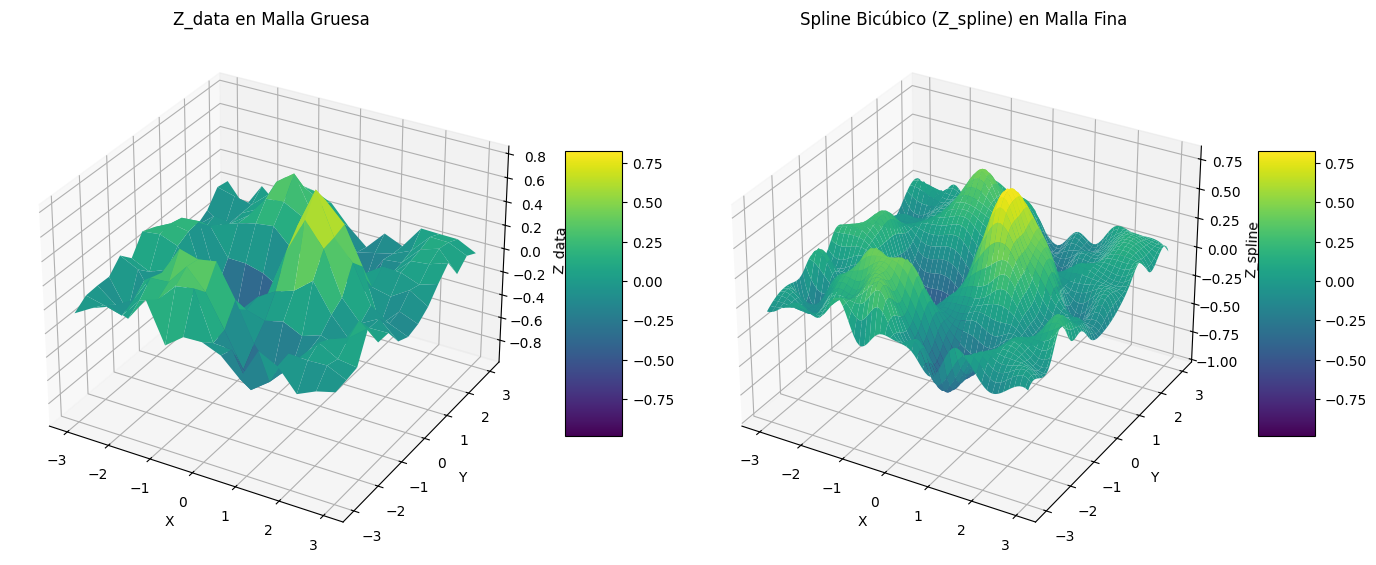

In [4]:
# TODO P2.2: figura comparativa datos vs spline

from mpl_toolkits.mplot3d import Axes3D

# Determinar los límites de color comunes
vmin_val = min(Z_data.min(), Z_spline.min())
vmax_val = max(Z_data.max(), Z_spline.max())

fig = plt.figure(figsize=(14, 6))

# Panel izquierdo: Z_data en la malla gruesa
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_raw, Y_raw, Z_data, cmap='viridis', vmin=vmin_val, vmax=vmax_val)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z_data')
ax1.set_title('Z_data en Malla Gruesa')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

# Panel derecho: superficie interpolada por el spline en la malla fina
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_fine, Y_fine, Z_spline, cmap='viridis', vmin=vmin_val, vmax=vmax_val)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z_spline')
ax2.set_title('Spline Bicúbico (Z_spline) en Malla Fina')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [5]:
# TODO P3.1: construcción de A y ajuste por mínimos cuadrados

# Flatten X_raw, Y_raw, and Z_data for constructing matrix A
x_flat = X_raw.flatten()
y_flat = Y_raw.flatten()
z_flat = Z_data.flatten()

# Construct matrix A for the model z = c0 + c1*x + c2*y
# A will have columns: [ones, x_flat, y_flat]
A = np.column_stack([np.ones_like(x_flat), x_flat, y_flat])

# Solve the normal system using np.linalg.lstsq
# The result is (coefficients, residuals, rank, singular_values)
coefficients, residuals, rank, singular_values = np.linalg.lstsq(A, z_flat, rcond=None)

c0, c1, c2 = coefficients

print(f"Coeficientes del plano ajustado:")
print(f"c0 = {c0:.4f}")
print(f"c1 = {c1:.4f}")
print(f"c2 = {c2:.4f}")

Coeficientes del plano ajustado:
c0 = 0.0036
c1 = 0.0005
c2 = 0.0036


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

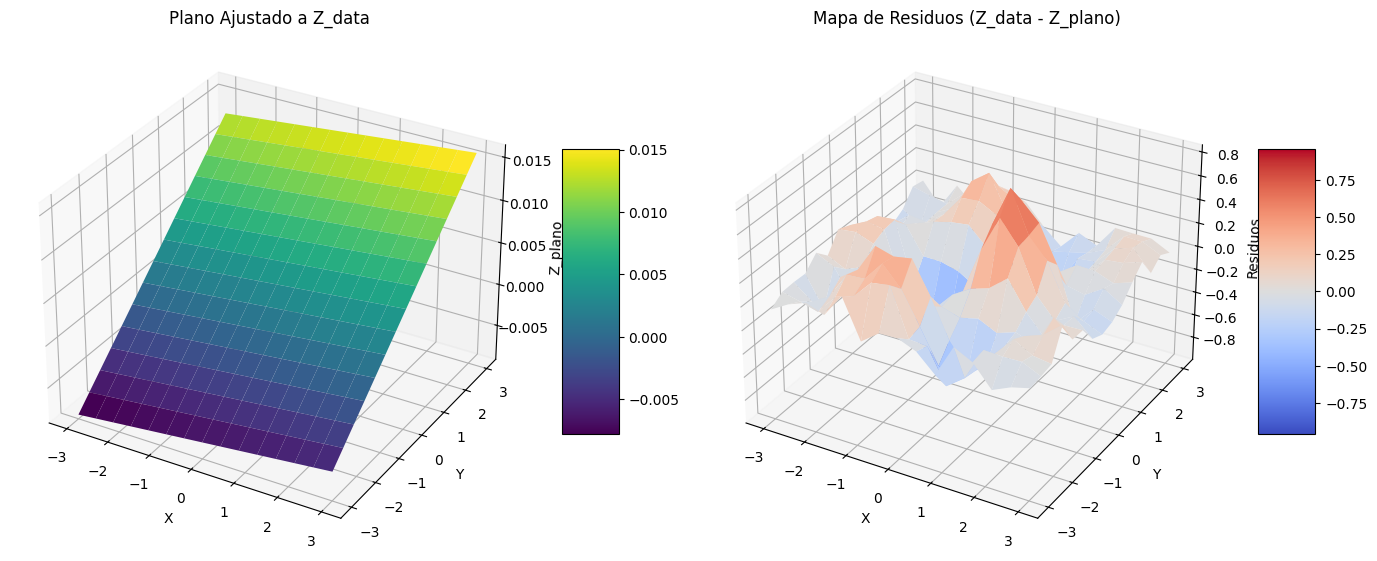

In [6]:
# TODO P3.2: plano ajustado y mapa de residuos

# 1. Calcular el plano ajustado en la malla gruesa
Z_plano = c0 + c1 * X_raw + c2 * Y_raw

# 2. Calcular el mapa de residuos
R = Z_data - Z_plano

# 3. Producir la figura con dos paneles
fig = plt.figure(figsize=(14, 6))

# Panel izquierdo: plano ajustado sobre la malla gruesa
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_raw, Y_raw, Z_plano, cmap='viridis') # Using viridis for the plane
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z_plano')
ax1.set_title('Plano Ajustado a Z_data')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

# Panel derecho: mapa de residuos R
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Determinar límites simétricos para el colormap divergente de los residuos
max_abs_residual = np.max(np.abs(R))
vmin_res = -max_abs_residual
vmax_res = max_abs_residual

surf2 = ax2.plot_surface(X_raw, Y_raw, R, cmap='coolwarm', vmin=vmin_res, vmax=vmax_res) # Divergent colormap centered at zero
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Residuos')
ax2.set_title('Mapa de Residuos (Z_data - Z_plano)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [ ]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
